In [329]:
# Add project root to path and enable auto-reload
import sys
sys.path.insert(0, '../..')

# Auto-reload modules before executing each cell
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [330]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor, XGBClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, make_scorer
from grid_intelligence.logic import preprocessor


In [ ]:
# Load data (interaction features now generated in preprocessor.py)

df_model = preprocessor.generate_features(nrows=60000)
df_model = df_model.iloc[-40000:]
df_model["target_288"] = df_model["price"].shift(-288)
split_idx = 27000

threshold_pos = 150
threshold_neg = 10

df_model["regime"] = 0  # normal
df_model.loc[df_model["price"] > threshold_pos, "regime"] = 1   # positive spike
df_model.loc[df_model["price"] < threshold_neg, "regime"] = 2  # negative spike

df_model = df_model.dropna().reset_index(drop=True)
train = df_model.iloc[:split_idx]
test = df_model.iloc[split_idx:]

columns_to_drop = ["price", "target_288", "regime", "datetime_utc"]

X_train = train.drop(columns=columns_to_drop)
y_train = train["target_288"]
y_regime_train = train["regime"]

X_test = test.drop(columns=columns_to_drop)
y_test = test["target_288"]
y_regime_test = test["regime"]

print(f"Features: {len(X_train.columns)}")
print(f"Shape - X_train: {X_train.shape}, X_test: {X_test.shape}")


/home/kimean/code/xucenying/grid-intelligence/notebooks/kim/../../grid_intelligence/logic/data.py:95: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns, UTC] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df["is_holiday"] = df[datetime_col].dt.floor("D").isin(de_holidays)
/home/kimean/code/xucenying/grid-intelligence/notebooks/kim/../../grid_intelligence/logic/data.py:124: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns, UTC] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df['is_holiday_288'] = future_timestamp.dt.floor("D").isin(de_holidays).astype(int)


Features: 164
Shape - X_train: (27000, 164), X_test: (12712, 164)


## Model Training: Multi-Regime XGBoost



=== PRODUCTION-REALISTIC PREDICTIONS (no lookahead) ===
MAE:  23.7419
RMSE: 35.1078

=== MAE by Regime ===
Normal (regime=0):    23.2100  (11145 samples)
Pos Spike (regime=1): 28.0775  (1155 samples)
Neg Spike (regime=2): 25.9736  (412 samples)
All Spikes (1+2):     27.5243  (1567 samples)


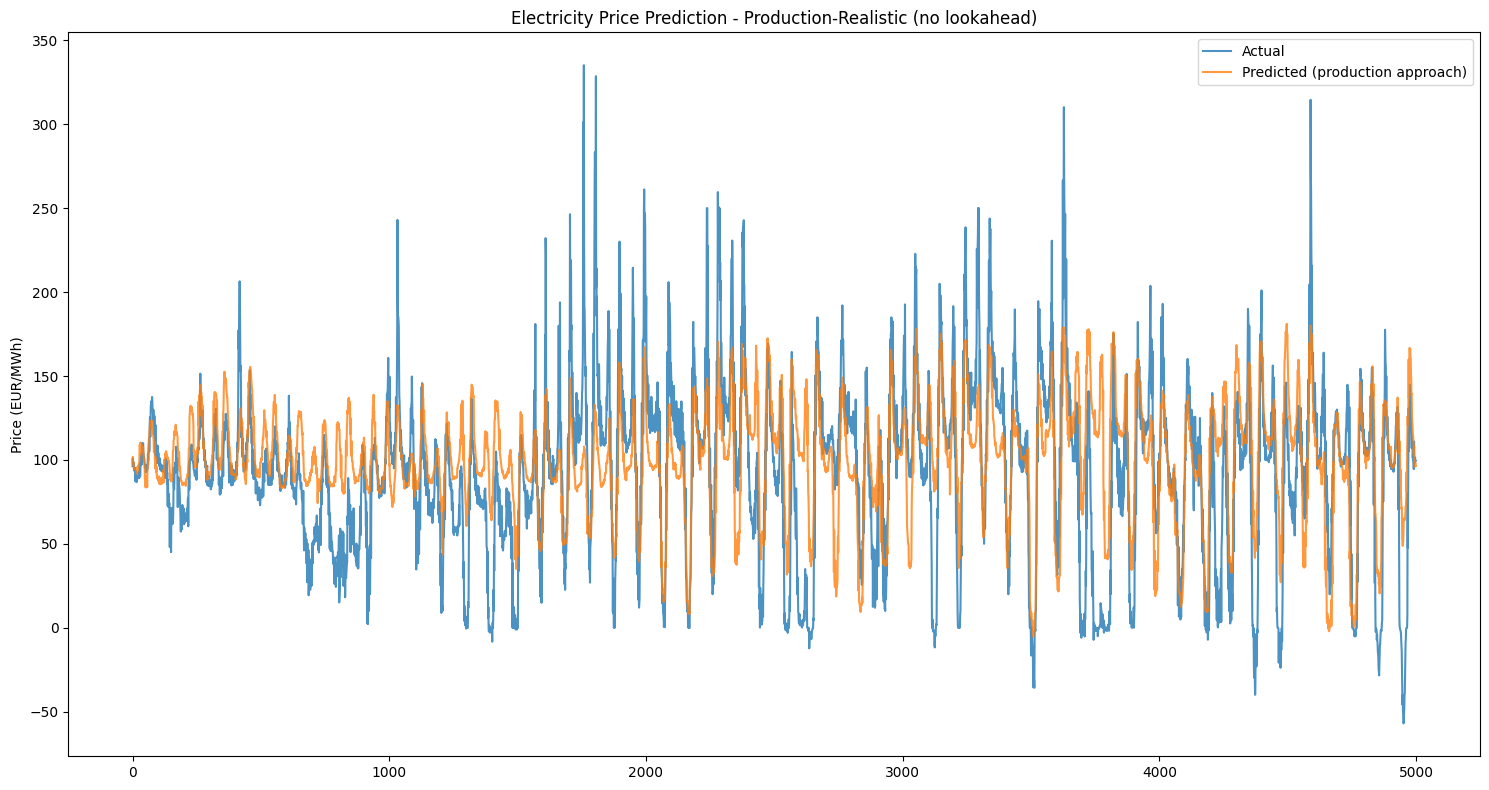

In [332]:
from xgboost import XGBRegressor
from sklearn.utils.class_weight import compute_sample_weight

# ── 1. Regime Classifier ──────────────────────────────────────────────────────
weights = compute_sample_weight(class_weight="balanced", y=y_regime_train)
clf = XGBClassifier(objective="multi:softprob", num_class=3)
clf.fit(X_train, y_regime_train, sample_weight=weights)

# ── 2. Regime-specific XGBoost Regressors ─────────────────────────────────────
xgb_params = dict(
    n_estimators=300, learning_rate=0.01, max_depth=6,
    subsample=1.0, colsample_bytree=0.7, random_state=42,
    reg_lambda=5, reg_alpha=0.1, gamma=0
)
model_normal = XGBRegressor(**xgb_params)
model_pos    = XGBRegressor(**xgb_params)
model_neg    = XGBRegressor(**xgb_params)

# Train only on recent data for positive spikes (last ~24k samples)
recent_mask = X_train.index > (len(X_train) - 24000)
model_normal.fit(X_train[y_regime_train == 0], y_train[y_regime_train == 0])
model_pos.fit(X_train[(y_regime_train == 1) & recent_mask], y_train[(y_regime_train == 1) & recent_mask])
model_neg.fit(X_train[y_regime_train == 2], y_train[y_regime_train == 2])


# ── 3. Regime-blended predictions with GARCH amplitude correction ─────────────
probs    = clf.predict_proba(X_test)
p_normal = probs[:, 0]
p_pos    = probs[:, 1]
p_neg    = probs[:, 2]

y_pred_soft = (
    p_neg    * model_neg.predict(X_test)    * 0.85 +
    p_normal * model_normal.predict(X_test)  +
    p_pos    * model_pos.predict(X_test)    * 0.9
)

# ── 4. Evaluation & Visualization ─────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae  = mean_absolute_error(y_test, y_pred_soft)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_soft))
print(f"\n=== PRODUCTION-REALISTIC PREDICTIONS (no lookahead) ===")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# Regime-specific MAE breakdown
normal_mask = y_regime_test == 0
pos_spike_mask = y_regime_test == 1
neg_spike_mask = y_regime_test == 2
spike_mask = (y_regime_test == 1) | (y_regime_test == 2)

mae_normal = mean_absolute_error(y_test[normal_mask], y_pred_soft[normal_mask]) if normal_mask.sum() > 0 else 0
mae_pos_spike = mean_absolute_error(y_test[pos_spike_mask], y_pred_soft[pos_spike_mask]) if pos_spike_mask.sum() > 0 else 0
mae_neg_spike = mean_absolute_error(y_test[neg_spike_mask], y_pred_soft[neg_spike_mask]) if neg_spike_mask.sum() > 0 else 0
mae_spike = mean_absolute_error(y_test[spike_mask], y_pred_soft[spike_mask]) if spike_mask.sum() > 0 else 0

print(f"\n=== MAE by Regime ===")
print(f"Normal (regime=0):    {mae_normal:.4f}  ({normal_mask.sum()} samples)")
print(f"Pos Spike (regime=1): {mae_pos_spike:.4f}  ({pos_spike_mask.sum()} samples)")
print(f"Neg Spike (regime=2): {mae_neg_spike:.4f}  ({neg_spike_mask.sum()} samples)")
print(f"All Spikes (1+2):     {mae_spike:.4f}  ({spike_mask.sum()} samples)")

# Visualization
fig, axes = plt.subplots(1, 1, figsize=(15, 8), sharex=False)
axes.plot(y_test[-5000:].values, label="Actual", alpha=0.8)
axes.plot(y_pred_soft[-5000:], label="Predicted (production approach)", alpha=0.8)
axes.legend()
axes.set_title("Electricity Price Prediction - Production-Realistic (no lookahead)")
axes.set_ylabel("Price (EUR/MWh)")


plt.tight_layout()
plt.show()


## Save Models for Production

Save all trained models to pickle files for use in main.py

In [334]:
import pickle
import os

# Create models directory if it doesn't exist
models_dir = '../../grid_intelligence/models/'
os.makedirs(models_dir, exist_ok=True)

# Save all models
models_to_save = {
    'regime_classifier.pkl': clf,
    'model_normal.pkl': model_normal,
    'model_pos.pkl': model_pos,
    'model_neg.pkl': model_neg,
    'model_config.pkl': {
        'threshold_pos': threshold_pos,
        'threshold_neg': threshold_neg,
        'xgb_params': xgb_params,
        'scaling_factors': {
            'neg': 0.85,
            'normal': 1.0,
            'pos': 0.9
        }
    }
}

print("Saving models to:", models_dir)
print("=" * 80)

for filename, model_obj in models_to_save.items():
    filepath = os.path.join(models_dir, filename)
    with open(filepath, 'wb') as f:
        pickle.dump(model_obj, f)
    print(f"✅ Saved: {filename}")

print("\n" + "=" * 80)
print("All models saved successfully!")
print(f"Location: {os.path.abspath(models_dir)}")
print("\nSaved models:")
print("  - regime_classifier.pkl: XGBoost regime classifier (3 classes)")
print("  - model_normal.pkl: XGBoost for normal regime")
print("  - model_pos.pkl: XGBoost for positive spike regime")
print("  - model_neg.pkl: XGBoost for negative spike regime")
print("  - model_config.pkl: Thresholds and scaling factors")

Saving models to: ../../grid_intelligence/models/
✅ Saved: regime_classifier.pkl
✅ Saved: model_normal.pkl
✅ Saved: model_pos.pkl
✅ Saved: model_neg.pkl
✅ Saved: model_config.pkl

All models saved successfully!
Location: /home/kimean/code/xucenying/grid-intelligence/grid_intelligence/models

Saved models:
  - regime_classifier.pkl: XGBoost regime classifier (3 classes)
  - model_normal.pkl: XGBoost for normal regime
  - model_pos.pkl: XGBoost for positive spike regime
  - model_neg.pkl: XGBoost for negative spike regime
  - model_config.pkl: Thresholds and scaling factors


In [302]:
from sklearn.metrics import recall_score

recall_class1 = recall_score(
    y_regime_test,
    clf.predict(X_test),
    labels=[1],
    average="macro"
)

print("Recall for class 1:", recall_class1)

Recall for class 1: 0.793073593073593
